In [ ]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import qmc, norm


In [ ]:
params = {
    "S0": 100.0,
    "K": 100.0,
    "r": 0.05,
    "sigma": 0.20,
    "T": 1.0,
    "m": 64
}

# Sobol / QMC: 2^k
N_grid = [2**k for k in range(8, 15)]   # 256, 512, ..., 16384

# how many repetitions under each n
R = 100

payoff functions

In [ ]:
def payoff_european_call(ST, K):
    """
    European call payoff: max(ST - K, 0)
    """
    return np.maximum(ST - K, 0.0)


def payoff_digital_call(ST, K):
    """
    Digital call payoff: 1{ST > K}
    Returns an undiscounted payoff in {0, 1}.
    """
    return (ST > K).astype(float)


def payoff_asian_call(paths, K, include_S0=False):
    """
    Arithmetic-average Asian call payoff:
        max(avg(S_ti) - K, 0)

    paths shape: (n, m+1)
    First column is S0
    """
    if include_S0:
        avg_price = np.mean(paths, axis=1)
    else:
        avg_price = np.mean(paths[:, 1:], axis=1)

    return np.maximum(avg_price - K, 0.0)

Black-Scholes closed-form truth for European and Digital

In [ ]:
def bs_d1_d2(S0, K, r, sigma, T):
    """
    Compute Black-Scholes d1 and d2.
    """
    d1 = (np.log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return d1, d2


def bs_call_price(S0, K, r, sigma, T):
    """
    Black-Scholes European call price under risk-neutral GBM.
    """
    d1, d2 = bs_d1_d2(S0, K, r, sigma, T)
    return S0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)


def bs_digital_call_price(S0, K, r, sigma, T):
    """
    Cash-or-nothing digital call price:
        e^{-rT} * P(ST > K) = e^{-rT} * Phi(d2)
    """
    _, d2 = bs_d1_d2(S0, K, r, sigma, T)
    return np.exp(-r * T) * norm.cdf(d2)

Exact GBM path simulation with MC

In [ ]:
def simulate_gbm_paths_mc(n, params, rng=None):
    """
    Simulate GBM paths using standard Monte Carlo (pseudo-random normals).

    Returns
    -------
    np.ndarray
        shape (n, m+1)
    """
    S0 = params["S0"]
    r = params["r"]
    sigma = params["sigma"]
    T = params["T"]
    m = params["m"]

    if rng is None:
        rng = np.random.default_rng()

    dt = T / m

    Z = rng.standard_normal(size=(n, m))
    increments = (r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z

    log_S_ratio = np.cumsum(increments, axis=1)
    S = S0 * np.exp(log_S_ratio)

    S_full = np.concatenate([np.full((n, 1), S0), S], axis=1)
    return S_full

Exact GBM path simulation with QMC (scrambled Sobol)

In [ ]:
def simulate_gbm_paths_qmc(n, params, scramble=True, seed=None):
    """
    Simulate GBM paths using randomized QMC with scrambled Sobol points.

    Returns
    -------
    np.ndarray
        shape (n, m+1)
    """
    S0 = params["S0"]
    r = params["r"]
    sigma = params["sigma"]
    T = params["T"]
    m = params["m"]

    dt = T / m

    sobol_engine = qmc.Sobol(d=m, scramble=scramble, seed=seed)
    U = sobol_engine.random(n=n)

    # Avoid norm.ppf(0) = -inf and norm.ppf(1) = +inf
    U = np.clip(U, 1e-12, 1 - 1e-12)

    Z = norm.ppf(U)

    increments = (r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z
    log_S_ratio = np.cumsum(increments, axis=1)
    S = S0 * np.exp(log_S_ratio)

    S_full = np.concatenate([np.full((n, 1), S0), S], axis=1)
    return S_full

Pilot diagnostic / degeneracy screening

In [ ]:
def pilot_diagnostic(params, n_pilot=100_000, seed=123):
    """
    Check whether the chosen parameter setting is near-degenerate
    for the three payoffs.
    """
    rng = np.random.default_rng(seed)
    paths = simulate_gbm_paths_mc(n_pilot, params, rng=rng)
    ST = paths[:, -1]

    call_payoff = payoff_european_call(ST, params["K"])
    digital_payoff = payoff_digital_call(ST, params["K"])
    asian_payoff = payoff_asian_call(paths, params["K"], include_S0=False)

    summary = {
        "call_positive_rate": np.mean(call_payoff > 0),
        "digital_itm_rate": np.mean(digital_payoff > 0),
        "asian_positive_rate": np.mean(asian_payoff > 0),
        "call_sample_variance": np.var(call_payoff, ddof=1),
        "digital_sample_variance": np.var(digital_payoff, ddof=1),
        "asian_sample_variance": np.var(asian_payoff, ddof=1),
        "call_mean_payoff": np.mean(call_payoff),
        "digital_mean_payoff": np.mean(digital_payoff),
        "asian_mean_payoff": np.mean(asian_payoff),
    }

    flags = {
        "call_near_degenerate": (
            summary["call_positive_rate"] < 0.05 or summary["call_positive_rate"] > 0.95
        ),
        "digital_near_degenerate": (
            summary["digital_itm_rate"] < 0.10 or summary["digital_itm_rate"] > 0.90
        ),
        "asian_near_degenerate": (
            summary["asian_positive_rate"] < 0.05 or summary["asian_positive_rate"] > 0.95
        ),
    }

    return summary, flags

summary, flags = pilot_diagnostic(params, n_pilot=100_000, seed=123)

print("Pilot diagnostic summary:")
for k, v in summary.items():
    print(f"{k}: {v:.6f}")

print("\nDegeneracy flags:")
for k, v in flags.items():
    print(f"{k}: {v}")

Pilot diagnostic summary:
call_positive_rate: 0.561230
digital_itm_rate: 0.561230
asian_positive_rate: 0.561600
call_sample_variance: 239.875193
digital_sample_variance: 0.246253
asian_sample_variance: 72.002837
call_mean_payoff: 10.991532
digital_mean_payoff: 0.561230
asian_mean_payoff: 6.146218

Degeneracy flags:
call_near_degenerate: False
digital_near_degenerate: False
asian_near_degenerate: False


One-run price estimator

In [ ]:
def estimate_price_once(method, payoff_type, n, params, seed=None):
    """
    Run one single price estimation for a given method and payoff.
    Returns discounted price estimate.
    """
    if method == "MC":
        rng = np.random.default_rng(seed)
        paths = simulate_gbm_paths_mc(n, params, rng=rng)
    elif method == "QMC":
        paths = simulate_gbm_paths_qmc(n, params, scramble=True, seed=seed)
    else:
        raise ValueError("method must be 'MC' or 'QMC'")

    K = params["K"]
    r = params["r"]
    T = params["T"]

    if payoff_type == "european_call":
        ST = paths[:, -1]
        payoff = payoff_european_call(ST, K)

    elif payoff_type == "digital_call":
        ST = paths[:, -1]
        payoff = payoff_digital_call(ST, K)

    elif payoff_type == "asian_call":
        payoff = payoff_asian_call(paths, K, include_S0=False)

    else:
        raise ValueError("Unsupported payoff_type")

    price_estimate = np.exp(-r * T) * np.mean(payoff)
    return price_estimate

True value helper

In [ ]:
def get_true_value(payoff_type, params):
    """
    Return the true value if closed form is available.
    For Asian call, return None for now.
    """
    S0 = params["S0"]
    K = params["K"]
    r = params["r"]
    sigma = params["sigma"]
    T = params["T"]

    if payoff_type == "european_call":
        return bs_call_price(S0, K, r, sigma, T)

    elif payoff_type == "digital_call":
        return bs_digital_call_price(S0, K, r, sigma, T)

    elif payoff_type == "asian_call":
        return None

    else:
        raise ValueError("Unsupported payoff_type")

Asian benchmark

In [ ]:
def compute_asian_benchmark(params, n_benchmark=2**18, R_benchmark=20, base_seed=5000):
    """
    Build a high-precision benchmark for the Asian call using large-sample randomized QMC.

    Returns
    -------
    benchmark_mean : float
    benchmark_se : float
    rep_estimates : np.ndarray
    """
    estimates = []

    for rep in range(R_benchmark):
        seed = base_seed + rep
        est = estimate_price_once(
            method="QMC",
            payoff_type="asian_call",
            n=n_benchmark,
            params=params,
            seed=seed
        )
        estimates.append(est)

    estimates = np.array(estimates)
    benchmark_mean = np.mean(estimates)
    benchmark_se = np.std(estimates, ddof=1) / np.sqrt(R_benchmark)

    return benchmark_mean, benchmark_se, estimates

Compute Asian benchmark

In [ ]:
asian_benchmark, asian_benchmark_se, asian_rep_estimates = compute_asian_benchmark(
    params,
    n_benchmark=2**18,
    R_benchmark=20,
    base_seed=5000
)

print("Asian benchmark:", asian_benchmark)
print("Asian benchmark SE across randomized QMC replications:", asian_benchmark_se)

Asian benchmark: 5.836818016911935
Asian benchmark SE across randomized QMC replications: 0.000537708336609566


Main experiment runner with runtime

In [ ]:
def run_experiment_for_payoff(payoff_type, params, N_grid, R=30, true_value=None, base_seed=1000):
    """
    Run the main experiment for one payoff type.

    For each sample size n and method (MC / QMC), repeat R times and compute:
    - mean estimator
    - estimator standard deviation across replications
    - estimator variance across replications
    - absolute bias
    - RMSE
    - average runtime per replication
    """
    rows = []

    for n in N_grid:
        for method in ["MC", "QMC"]:
            estimates = []
            runtimes = []

            for rep in range(R):
                seed = base_seed + 10000 * (0 if method == "MC" else 1) + rep

                t0 = time.perf_counter()
                est = estimate_price_once(
                    method=method,
                    payoff_type=payoff_type,
                    n=n,
                    params=params,
                    seed=seed
                )
                t1 = time.perf_counter()

                estimates.append(est)
                runtimes.append(t1 - t0)

            estimates = np.array(estimates)
            runtimes = np.array(runtimes)

            mean_estimate = np.mean(estimates)
            sd_estimate = np.std(estimates, ddof=1)
            variance_estimate = sd_estimate**2

            mean_runtime = np.mean(runtimes)
            sd_runtime = np.std(runtimes, ddof=1)

            if true_value is not None:
                abs_bias = abs(mean_estimate - true_value)
                rmse = np.sqrt(np.mean((estimates - true_value)**2))
            else:
                abs_bias = np.nan
                rmse = np.nan

            rows.append({
                "payoff": payoff_type,
                "method": method,
                "n": n,
                "R": R,
                "true_value": true_value,
                "mean_estimate": mean_estimate,
                "sd_estimate": sd_estimate,
                "variance_estimate": variance_estimate,
                "abs_bias": abs_bias,
                "rmse": rmse,
                "mean_runtime": mean_runtime,
                "sd_runtime": sd_runtime
            })

    return pd.DataFrame(rows)

Run all three payoff experiments

In [ ]:
true_european = get_true_value("european_call", params)
true_digital = get_true_value("digital_call", params)
true_asian = asian_benchmark

df_european = run_experiment_for_payoff(
    payoff_type="european_call",
    params=params,
    N_grid=N_grid,
    R=R,
    true_value=true_european,
    base_seed=1000
)

df_digital = run_experiment_for_payoff(
    payoff_type="digital_call",
    params=params,
    N_grid=N_grid,
    R=R,
    true_value=true_digital,
    base_seed=2000
)

df_asian = run_experiment_for_payoff(
    payoff_type="asian_call",
    params=params,
    N_grid=N_grid,
    R=R,
    true_value=true_asian,
    base_seed=3000
)

df_results = pd.concat([df_european, df_digital, df_asian], ignore_index=True)
df_results = df_results.sort_values(["payoff", "n", "method"]).reset_index(drop=True)

df_results.head(12)

,payoff,method,n,R,true_value,mean_estimate,sd_estimate,variance_estimate,abs_bias,rmse,mean_runtime,sd_runtime
0,asian_call,MC,256,100,5.836818,5.932753,0.467070,0.218154,0.095935,0.474528,0.000785,0.000107
1,asian_call,QMC,256,100,5.836818,5.830286,0.120759,0.014583,0.006532,0.120331,0.007006,0.000698
2,asian_call,MC,512,100,5.836818,5.849374,0.332948,0.110854,0.012556,0.331517,0.001297,0.000052
3,asian_call,QMC,512,100,5.836818,5.828305,0.076327,0.005826,0.008513,0.076420,0.007984,0.000361
4,asian_call,MC,1024,100,5.836818,5.839187,0.265362,0.070417,0.002369,0.264042,0.002531,0.000282
5,asian_call,QMC,1024,100,5.836818,5.839860,0.040597,0.001648,0.003042,0.040508,0.017603,0.010714
6,asian_call,MC,2048,100,5.836818,5.840580,0.199455,0.039782,0.003762,0.198491,0.007314,0.002123
7,asian_call,QMC,2048,100,5.836818,5.837546,0.029624,0.000878,0.000728,0.029484,0.020700,0.005927
8,asian_call,MC,4096,100,5.836818,5.831931,0.118426,0.014025,0.004887,0.117934,0.012353,0.002002
9,asian_call,QMC,4096,100,5.836818,5.839019,0.019739,0.000390,0.002201,0.019763,0.038009,0.008932


Build comparison table

In [ ]:
def build_variance_comparison_table(df_results):
    """
    Build a comparison table containing:
    - variance_mc
    - variance_qmc
    - vrf = variance_mc / variance_qmc
    - variance_ratio = variance_qmc / variance_mc
    - scaled_variance_mc = n * variance_mc
    - scaled_variance_qmc = n * variance_qmc
    - runtime_mc
    - runtime_qmc
    - runtime_ratio = runtime_qmc / runtime_mc
    """
    mc = df_results[df_results["method"] == "MC"][
        ["payoff", "n", "variance_estimate", "mean_runtime", "rmse", "abs_bias", "sd_estimate"]
    ].copy()

    qmc = df_results[df_results["method"] == "QMC"][
        ["payoff", "n", "variance_estimate", "mean_runtime", "rmse", "abs_bias", "sd_estimate"]
    ].copy()

    merged = mc.merge(qmc, on=["payoff", "n"], suffixes=("_mc", "_qmc"))

    merged = merged.rename(columns={
        "variance_estimate_mc": "variance_mc",
        "variance_estimate_qmc": "variance_qmc",
        "mean_runtime_mc": "runtime_mc",
        "mean_runtime_qmc": "runtime_qmc",
        "rmse_mc": "rmse_mc",
        "rmse_qmc": "rmse_qmc",
        "abs_bias_mc": "abs_bias_mc",
        "abs_bias_qmc": "abs_bias_qmc",
        "sd_estimate_mc": "sd_mc",
        "sd_estimate_qmc": "sd_qmc"
    })

    merged["vrf"] = merged["variance_mc"] / merged["variance_qmc"]
    merged["variance_ratio"] = merged["variance_qmc"] / merged["variance_mc"]

    merged["scaled_variance_mc"] = merged["n"] * merged["variance_mc"]
    merged["scaled_variance_qmc"] = merged["n"] * merged["variance_qmc"]

    merged["runtime_ratio"] = merged["runtime_qmc"] / merged["runtime_mc"]

    merged["rmse_ratio"] = merged["rmse_qmc"] / merged["rmse_mc"]
    merged["sd_ratio"] = merged["sd_qmc"] / merged["sd_mc"]

    return merged

df_compare = build_variance_comparison_table(df_results)
df_compare

,payoff,n,variance_mc,runtime_mc,rmse_mc,abs_bias_mc,sd_mc,variance_qmc,runtime_qmc,rmse_qmc,abs_bias_qmc,sd_qmc,vrf,variance_ratio,scaled_variance_mc,scaled_variance_qmc,runtime_ratio,rmse_ratio,sd_ratio
0,asian_call,256,0.218154,0.000785,0.474528,0.095935,0.467070,0.014583,0.007006,0.120331,0.006532,0.120759,14.959704,0.066846,55.847538,3.733198,8.925724,0.253581,0.258546
1,asian_call,512,0.110854,0.001297,0.331517,0.012556,0.332948,0.005826,0.007984,0.076420,0.008513,0.076327,19.028255,0.052553,56.757455,2.982799,6.154366,0.230516,0.229245
2,asian_call,1024,0.070417,0.002531,0.264042,0.002369,0.265362,0.001648,0.017603,0.040508,0.003042,0.040597,42.726234,0.023405,72.106800,1.687647,6.954219,0.153414,0.152986
3,asian_call,2048,0.039782,0.007314,0.198491,0.003762,0.199455,0.000878,0.020700,0.029484,0.000728,0.029624,45.332160,0.022059,81.474016,1.797267,2.830068,0.148543,0.148524
4,asian_call,4096,0.014025,0.012353,0.117934,0.004887,0.118426,0.000390,0.038009,0.019763,0.002201,0.019739,35.994122,0.027782,57.445691,1.595974,3.076810,0.167580,0.166680
5,asian_call,8192,0.006615,0.021780,0.081186,0.006486,0.081334,0.000161,0.066280,0.012615,0.000173,0.012677,41.160574,0.024295,54.192282,1.316607,3.043197,0.155385,0.155869
6,asian_call,16384,0.003895,0.064077,0.062481,0.006924,0.062409,0.000075,0.122145,0.008607,0.000018,0.008650,52.052518,0.019211,63.813323,1.225941,1.906222,0.137752,0.138605
7,digital_call,256,0.000736,0.000670,0.027143,0.002906,0.027123,0.000355,0.006727,0.018760,0.000921,0.018832,2.074314,0.482087,0.188328,0.090790,10.042537,0.691167,0.694325
8,digital_call,512,0.000384,0.001323,0.019791,0.003445,0.019587,0.000141,0.008013,0.011824,0.000327,0.011879,2.719078,0.367772,0.196436,0.072243,6.056448,0.597412,0.606442
9,digital_call,1024,0.000158,0.002521,0.012955,0.003306,0.012589,0.000063,0.010648,0.008048,0.001404,0.007964,2.498817,0.400189,0.162293,0.064948,4.223040,0.621193,0.632605


In [ ]:
summary_table = df_results[
    ["payoff", "method", "n", "mean_estimate", "sd_estimate", "rmse", "mean_runtime"]
].copy()

summary_table = summary_table.sort_values(["payoff", "n", "method"]).reset_index(drop=True)
summary_table

,payoff,method,n,mean_estimate,sd_estimate,rmse,mean_runtime
0,asian_call,MC,256,5.932753,0.467070,0.474528,0.000785
1,asian_call,QMC,256,5.830286,0.120759,0.120331,0.007006
2,asian_call,MC,512,5.849374,0.332948,0.331517,0.001297
3,asian_call,QMC,512,5.828305,0.076327,0.076420,0.007984
4,asian_call,MC,1024,5.839187,0.265362,0.264042,0.002531
5,asian_call,QMC,1024,5.839860,0.040597,0.040508,0.017603
6,asian_call,MC,2048,5.840580,0.199455,0.198491,0.007314
7,asian_call,QMC,2048,5.837546,0.029624,0.029484,0.020700
8,asian_call,MC,4096,5.831931,0.118426,0.117934,0.012353
9,asian_call,QMC,4096,5.839019,0.019739,0.019763,0.038009


RMSE by payoff

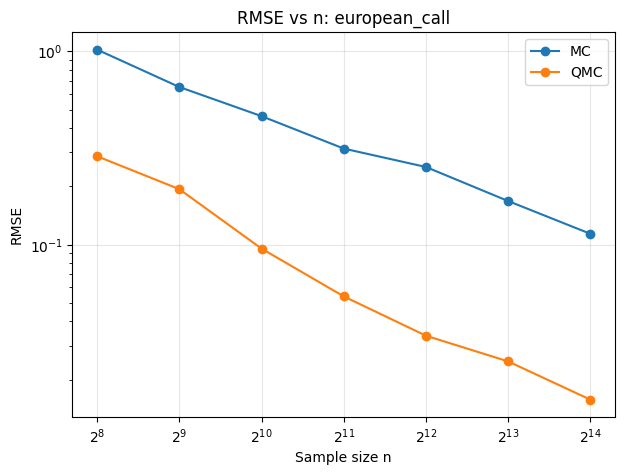

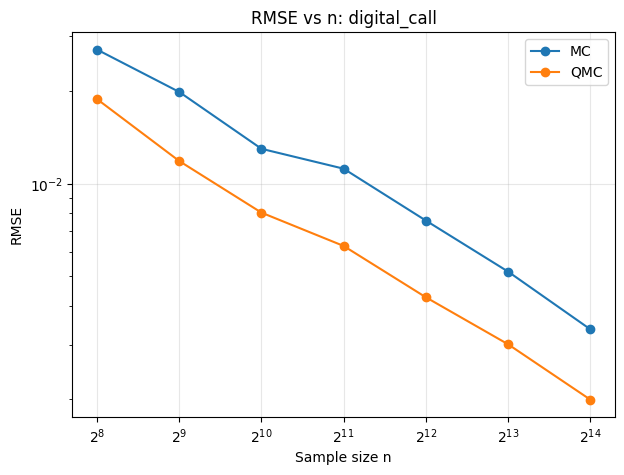

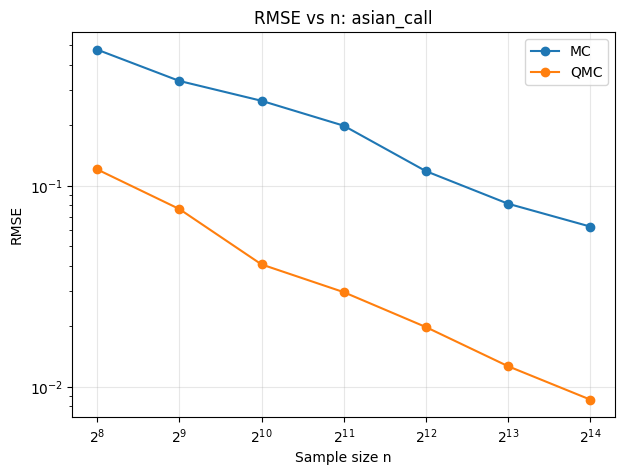

In [ ]:
def plot_rmse_by_payoff(df_results, payoff_type):
    df_sub = df_results[df_results["payoff"] == payoff_type].copy()

    plt.figure(figsize=(7, 5))

    for method in ["MC", "QMC"]:
        df_method = df_sub[df_sub["method"] == method].sort_values("n")
        plt.plot(df_method["n"], df_method["rmse"], marker="o", label=method)

    plt.xscale("log", base=2)
    plt.yscale("log")
    plt.xlabel("Sample size n")
    plt.ylabel("RMSE")
    plt.title(f"RMSE vs n: {payoff_type}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

plot_rmse_by_payoff(df_results, "european_call")
plot_rmse_by_payoff(df_results, "digital_call")
plot_rmse_by_payoff(df_results, "asian_call")

Absolute bias by payoff

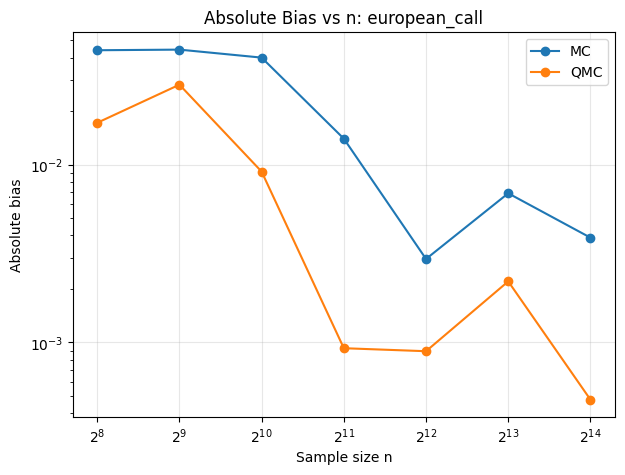

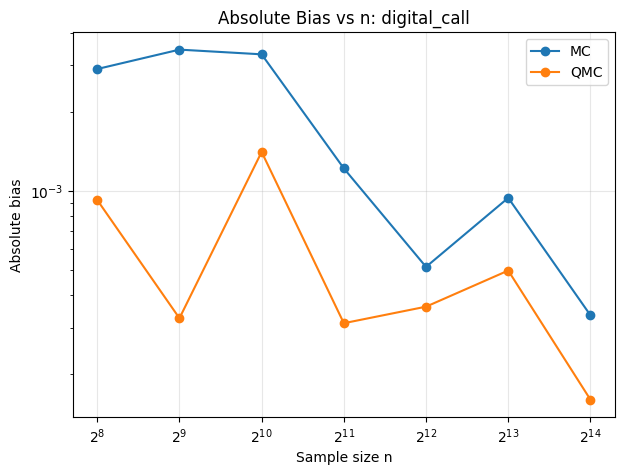

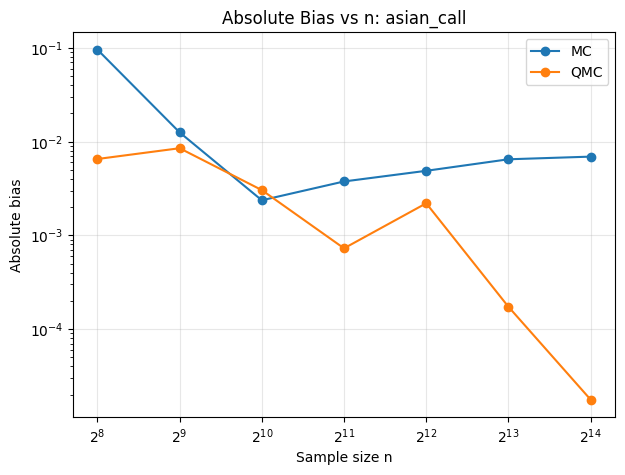

In [ ]:
def plot_abs_bias_by_payoff(df_results, payoff_type):
    df_sub = df_results[df_results["payoff"] == payoff_type].copy()

    plt.figure(figsize=(7, 5))

    for method in ["MC", "QMC"]:
        df_method = df_sub[df_sub["method"] == method].sort_values("n")
        plt.plot(df_method["n"], df_method["abs_bias"], marker="o", label=method)

    plt.xscale("log", base=2)
    plt.yscale("log")
    plt.xlabel("Sample size n")
    plt.ylabel("Absolute bias")
    plt.title(f"Absolute Bias vs n: {payoff_type}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

plot_abs_bias_by_payoff(df_results, "european_call")
plot_abs_bias_by_payoff(df_results, "digital_call")
plot_abs_bias_by_payoff(df_results, "asian_call")

Estimator SD by payoff

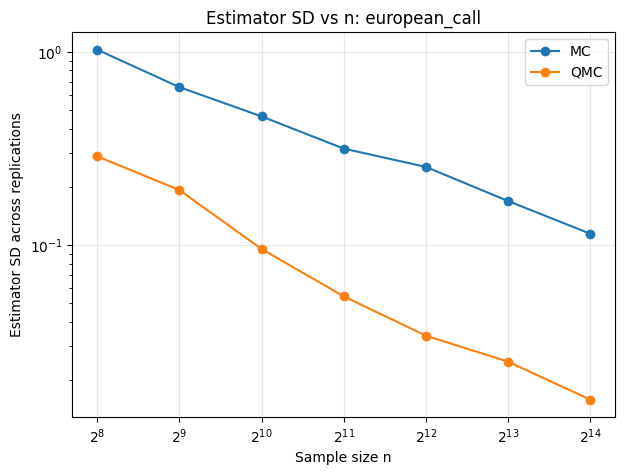

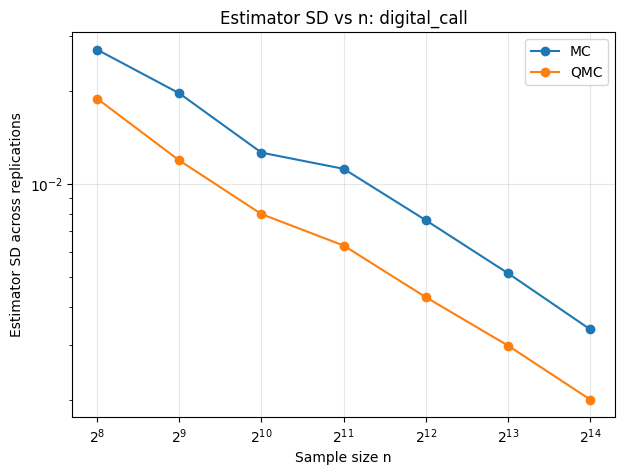

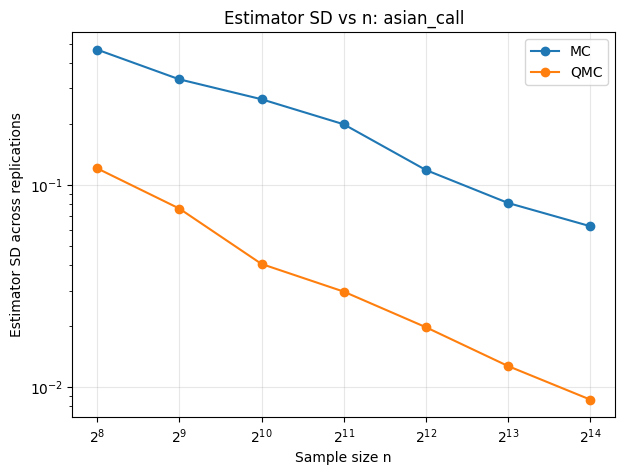

In [ ]:
def plot_sd_by_payoff(df_results, payoff_type):
    df_sub = df_results[df_results["payoff"] == payoff_type].copy()

    plt.figure(figsize=(7, 5))

    for method in ["MC", "QMC"]:
        df_method = df_sub[df_sub["method"] == method].sort_values("n")
        plt.plot(df_method["n"], df_method["sd_estimate"], marker="o", label=method)

    plt.xscale("log", base=2)
    plt.yscale("log")
    plt.xlabel("Sample size n")
    plt.ylabel("Estimator SD across replications")
    plt.title(f"Estimator SD vs n: {payoff_type}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

plot_sd_by_payoff(df_results, "european_call")
plot_sd_by_payoff(df_results, "digital_call")
plot_sd_by_payoff(df_results, "asian_call")

VRF for all payoffs

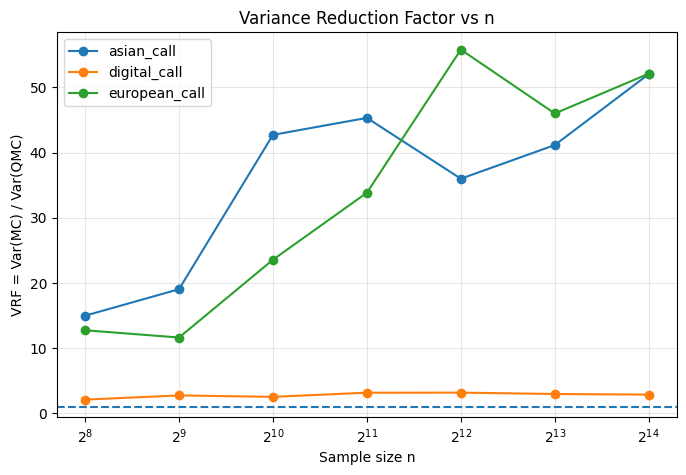

In [ ]:
def plot_vrf(df_compare):
    plt.figure(figsize=(8, 5))

    for payoff_type in df_compare["payoff"].unique():
        df_sub = df_compare[df_compare["payoff"] == payoff_type].sort_values("n")
        plt.plot(df_sub["n"], df_sub["vrf"], marker="o", label=payoff_type)

    plt.xscale("log", base=2)
    plt.xlabel("Sample size n")
    plt.ylabel("VRF = Var(MC) / Var(QMC)")
    plt.title("Variance Reduction Factor vs n")
    plt.axhline(1.0, linestyle="--")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

plot_vrf(df_compare)

Variance ratio for all payoffs

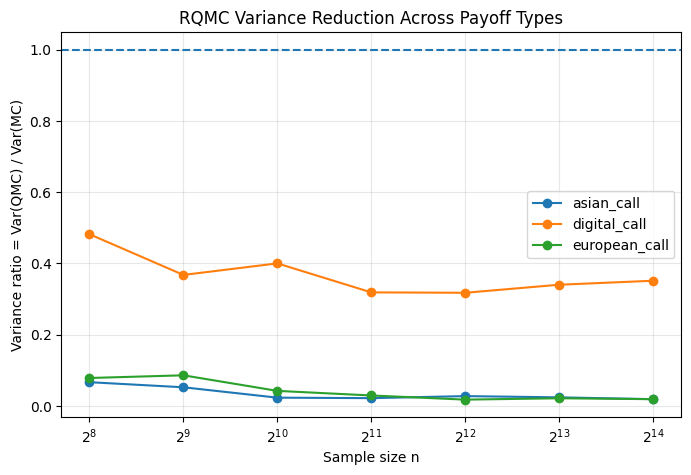

In [ ]:
def plot_variance_ratio_all_payoffs(df_compare):
    """
    Plot Var(QMC)/Var(MC) for all payoffs.
    Smaller means stronger QMC improvement.
    """
    plt.figure(figsize=(8, 5))

    for payoff_type in df_compare["payoff"].unique():
        df_sub = df_compare[df_compare["payoff"] == payoff_type].sort_values("n")
        plt.plot(df_sub["n"], df_sub["variance_ratio"], marker="o", label=payoff_type)

    plt.axhline(1.0, linestyle="--")
    plt.xscale("log", base=2)
    plt.xlabel("Sample size n")
    plt.ylabel("Variance ratio = Var(QMC) / Var(MC)")
    plt.title("RQMC Variance Reduction Across Payoff Types")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

plot_variance_ratio_all_payoffs(df_compare)

Scaled variance for one payoff

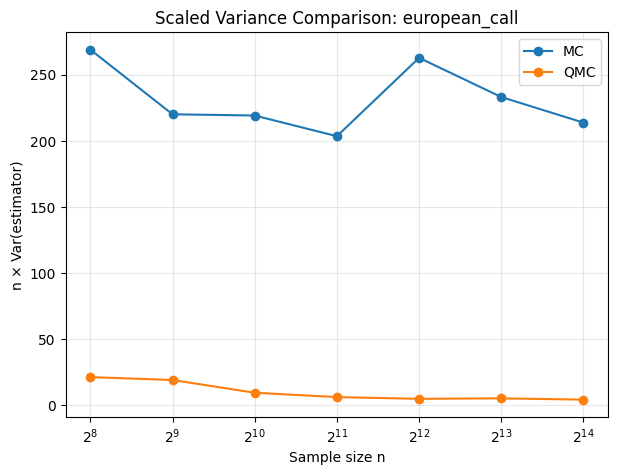

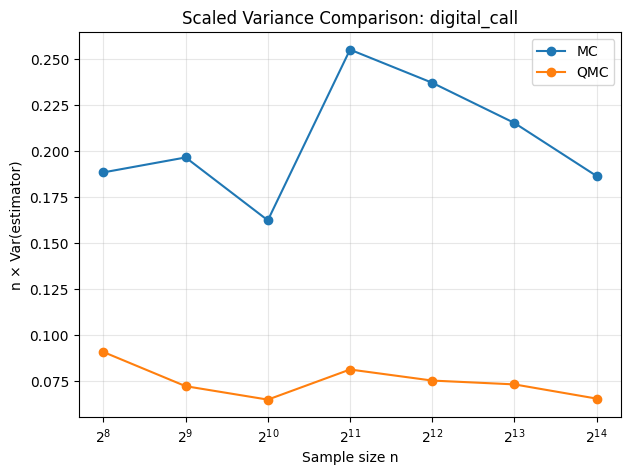

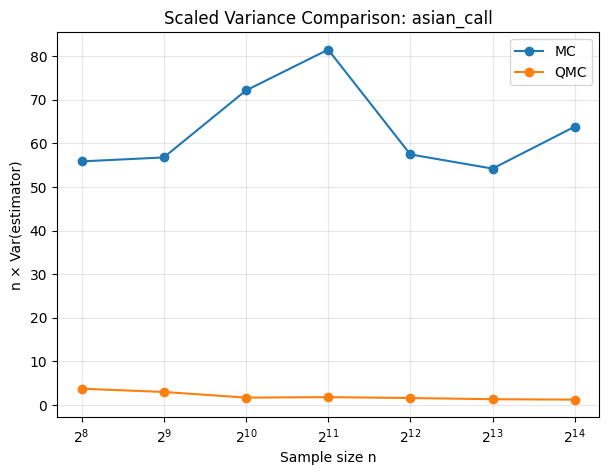

In [ ]:
def plot_scaled_variance(df_compare, payoff_type):
    df_sub = df_compare[df_compare["payoff"] == payoff_type].sort_values("n")

    plt.figure(figsize=(7, 5))
    plt.plot(df_sub["n"], df_sub["scaled_variance_mc"], marker="o", label="MC")
    plt.plot(df_sub["n"], df_sub["scaled_variance_qmc"], marker="o", label="QMC")

    plt.xscale("log", base=2)
    plt.xlabel("Sample size n")
    plt.ylabel("n × Var(estimator)")
    plt.title(f"Scaled Variance Comparison: {payoff_type}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

plot_scaled_variance(df_compare, "european_call")
plot_scaled_variance(df_compare, "digital_call")
plot_scaled_variance(df_compare, "asian_call")

Runtime for one payoff

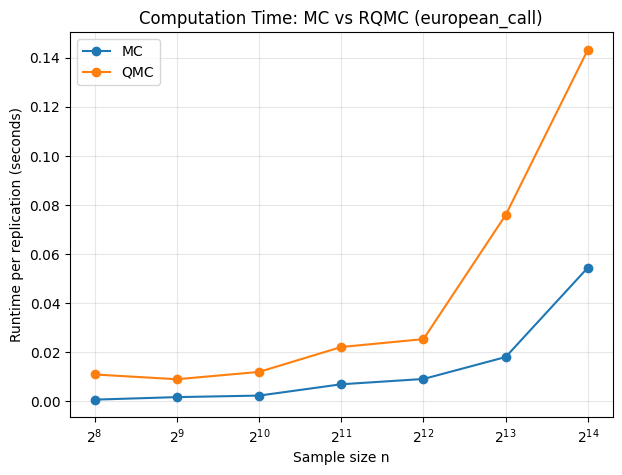

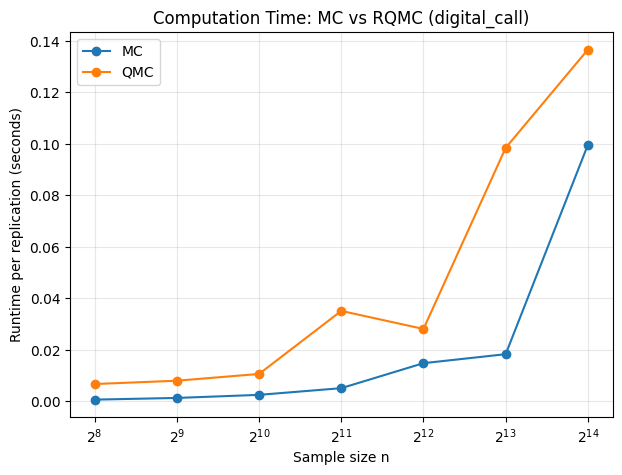

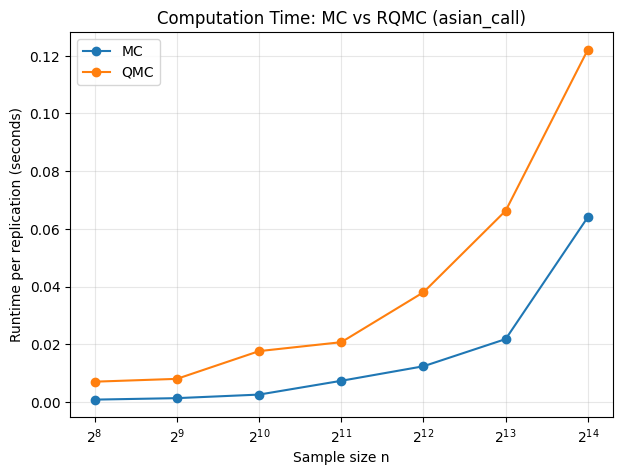

In [ ]:
def plot_runtime(df_compare, payoff_type):
    df_sub = df_compare[df_compare["payoff"] == payoff_type].sort_values("n")

    plt.figure(figsize=(7, 5))
    plt.plot(df_sub["n"], df_sub["runtime_mc"], marker="o", label="MC")
    plt.plot(df_sub["n"], df_sub["runtime_qmc"], marker="o", label="QMC")

    plt.xscale("log", base=2)
    plt.xlabel("Sample size n")
    plt.ylabel("Runtime per replication (seconds)")
    plt.title(f"Computation Time: MC vs RQMC ({payoff_type})")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

plot_runtime(df_compare, "european_call")
plot_runtime(df_compare, "digital_call")
plot_runtime(df_compare, "asian_call")

Three-panel figure for one payoff

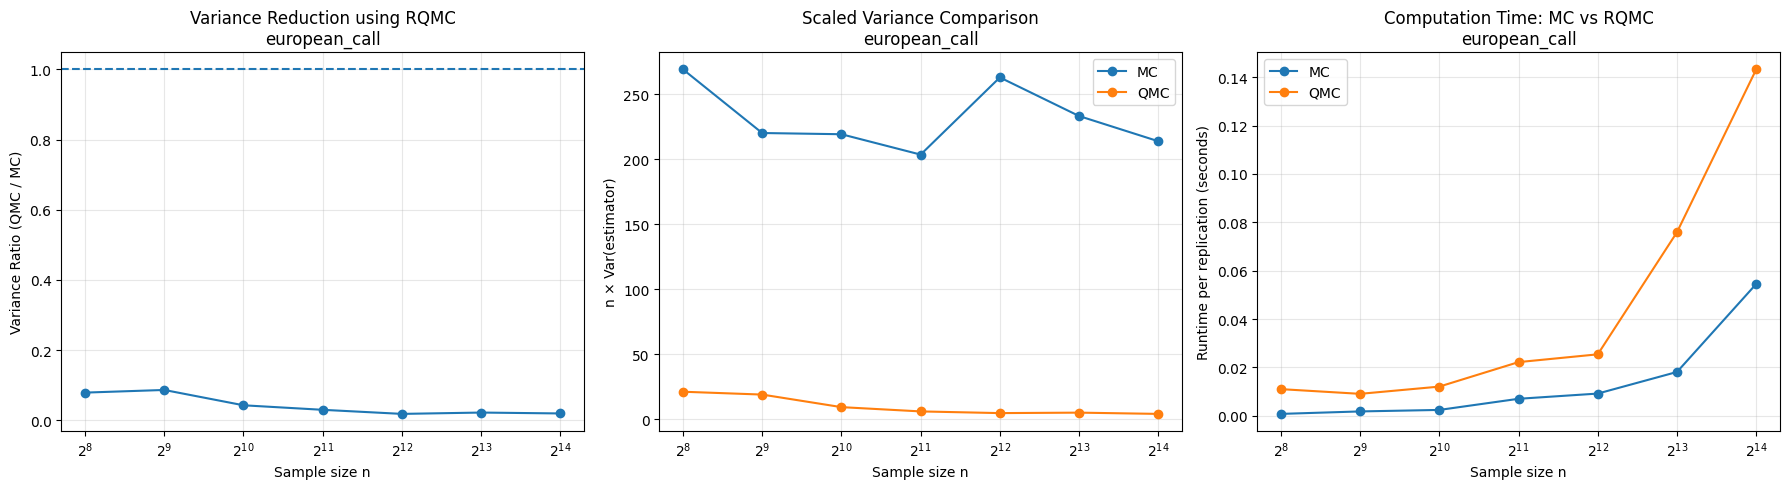

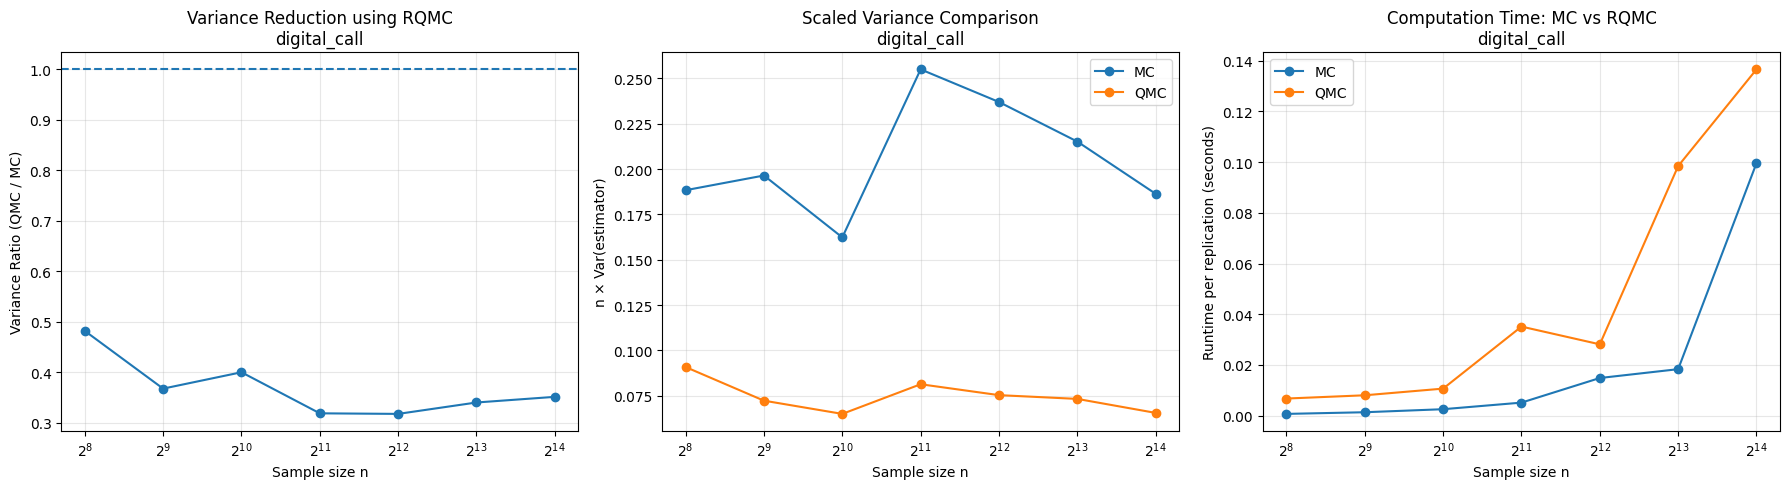

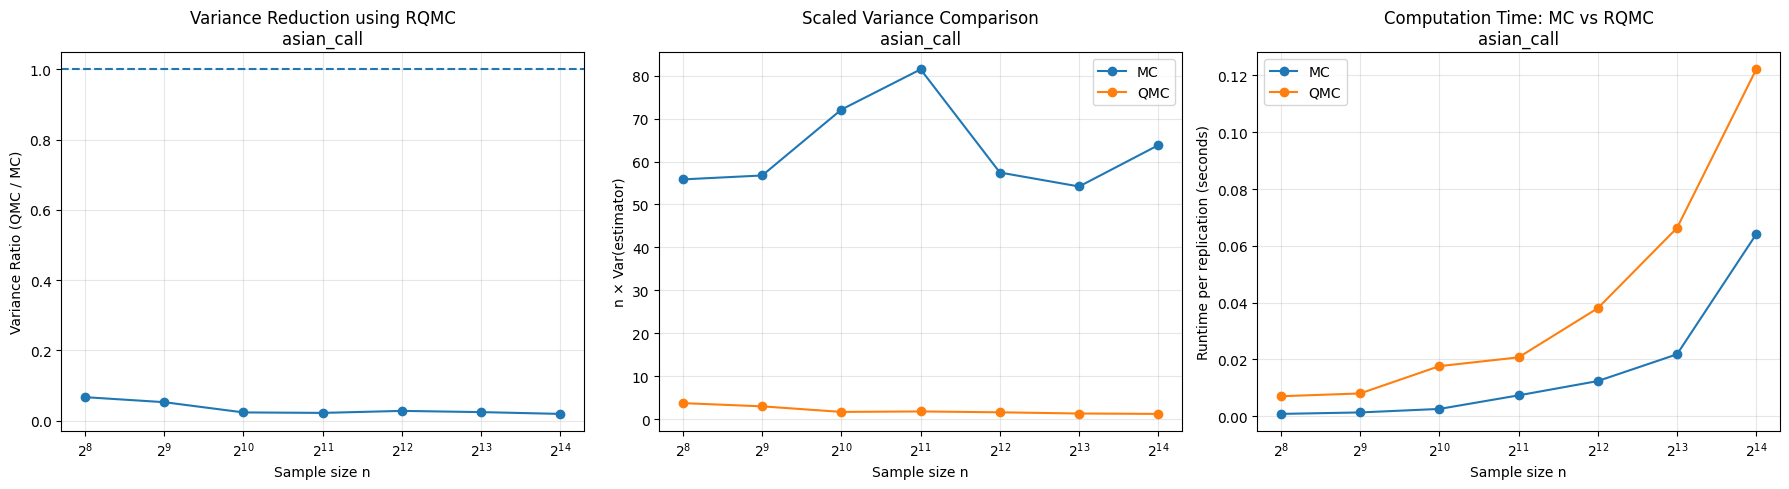

In [ ]:
def plot_reduction_and_runtime_triptych(df_compare, payoff_type):
    df_sub = df_compare[df_compare["payoff"] == payoff_type].sort_values("n")

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Panel 1: variance ratio
    axes[0].plot(df_sub["n"], df_sub["variance_ratio"], marker="o", label="QMC / MC")
    axes[0].axhline(1.0, linestyle="--")
    axes[0].set_xscale("log", base=2)
    axes[0].set_xlabel("Sample size n")
    axes[0].set_ylabel("Variance Ratio (QMC / MC)")
    axes[0].set_title(f"Variance Reduction using RQMC\n{payoff_type}")
    axes[0].grid(True, alpha=0.3)

    # Panel 2: scaled variance
    axes[1].plot(df_sub["n"], df_sub["scaled_variance_mc"], marker="o", label="MC")
    axes[1].plot(df_sub["n"], df_sub["scaled_variance_qmc"], marker="o", label="QMC")
    axes[1].set_xscale("log", base=2)
    axes[1].set_xlabel("Sample size n")
    axes[1].set_ylabel("n × Var(estimator)")
    axes[1].set_title(f"Scaled Variance Comparison\n{payoff_type}")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    # Panel 3: runtime
    axes[2].plot(df_sub["n"], df_sub["runtime_mc"], marker="o", label="MC")
    axes[2].plot(df_sub["n"], df_sub["runtime_qmc"], marker="o", label="QMC")
    axes[2].set_xscale("log", base=2)
    axes[2].set_xlabel("Sample size n")
    axes[2].set_ylabel("Runtime per replication (seconds)")
    axes[2].set_title(f"Computation Time: MC vs RQMC\n{payoff_type}")
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_reduction_and_runtime_triptych(df_compare, "european_call")
plot_reduction_and_runtime_triptych(df_compare, "digital_call")
plot_reduction_and_runtime_triptych(df_compare, "asian_call")

Quick summary at largest n

In [ ]:
def quick_summary_from_compare(df_compare):
    max_n = df_compare["n"].max()
    df_last = df_compare[df_compare["n"] == max_n].copy()

    print(f"Quick summary at the largest sample size n = {max_n}:")
    for _, row in df_last.iterrows():
        payoff = row["payoff"]
        vrf = row["vrf"]
        ratio = row["variance_ratio"]
        runtime_ratio = row["runtime_ratio"]
        print(
            f"  {payoff}: VRF = {vrf:.4f}, "
            f"Var(QMC)/Var(MC) = {ratio:.4f}, "
            f"Runtime(QMC)/Runtime(MC) = {runtime_ratio:.4f}"
        )

    quick_summary_from_compare(df_compare)